# Medical Image Preprocessing - Skin Cancer (HAM10000)

In this notebook, we perform preprocessing on the HAM10000 skin cancer dataset.

### Objectives:
- Load dataset from Kaggle
- Explore sample images
- Apply preprocessing steps:
  - Grayscale conversion
  - Gaussian filtering
  - Median filtering
- Compare filters performance
- Analyze noise effect on images

This step is essential before segmentation and classification.

In [ ]:
def setup_kaggle():
    from google.colab import files
    files.upload()  # upload kaggle.json

    !pip install -q kaggle

    import os
    os.makedirs('/root/.kaggle', exist_ok=True)
    !mv kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json

In [ ]:
setup_kaggle()

Saving kaggle.json to kaggle.json


In [ ]:
def download_dataset():
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
    !unzip -q skin-cancer-mnist-ham10000.zip
    print("Dataset downloaded and extracted ")

In [ ]:
download_dataset()

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:00<00:00, 92.3MB/s]

Dataset downloaded and extracted 


## Dataset Metadata

We load metadata to understand image labels and structure.

In [ ]:
def load_metadata():
    import pandas as pd
    df = pd.read_csv("HAM10000_metadata.csv")
    print("Shape:", df.shape)
    return df

df = load_metadata()
df.head()

Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Load Image Paths

Collect all image paths for processing.

In [ ]:
def load_image_paths(base_path="/content"):
    import os
    image_paths = []

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(".jpg"):
                image_paths.append(os.path.join(root, file))

    print("Total images:", len(image_paths))
    return image_paths

image_paths = load_image_paths()

Total images: 20030


## Sample Images Visualization

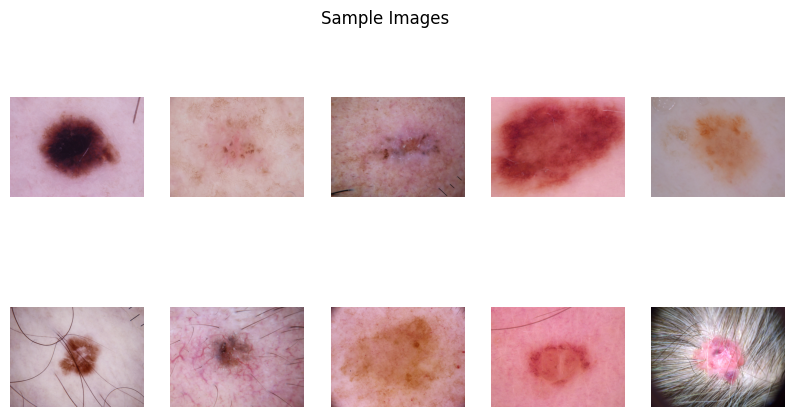

In [ ]:
def show_samples(image_paths, n=10):
    import random
    import cv2
    import matplotlib.pyplot as plt

    sample_paths = random.sample(image_paths, n)

    plt.figure(figsize=(10,5))

    for i, path in enumerate(sample_paths):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,5,i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle("Sample Images")
    plt.show()

    return sample_paths

sample_paths = show_samples(image_paths)

## Preprocessing Functions

In [ ]:
import cv2

def convert_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def apply_gaussian(gray):
    return cv2.GaussianBlur(gray, (5,5), 0)

def apply_median(gray):
    return cv2.medianBlur(gray, 5)

## Single Image Preprocessing

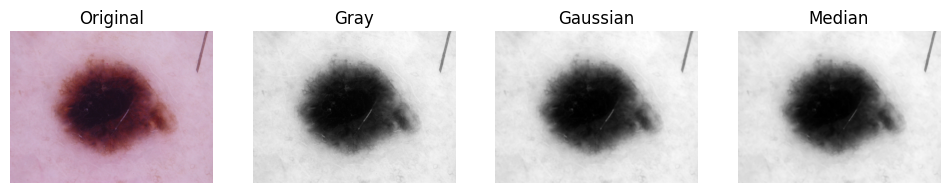

In [ ]:
def preprocess_single_image(path):
    import cv2
    import matplotlib.pyplot as plt

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = convert_to_gray(img)
    gaussian = apply_gaussian(gray)
    median = apply_median(gray)

    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(gray, cmap='gray')
    plt.title("Gray")
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(gaussian, cmap='gray')
    plt.title("Gaussian")
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(median, cmap='gray')
    plt.title("Median")
    plt.axis('off')

    plt.show()

preprocess_single_image(sample_paths[0])

## Comparison Between Filters

- Gaussian: smooths image but may blur edges  
- Median: preserves edges better

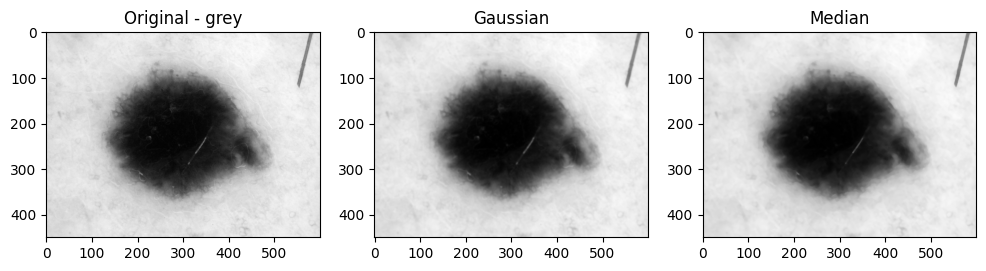

In [ ]:
def compare_filters(gray):
    import matplotlib.pyplot as plt

    gaussian = apply_gaussian(gray)
    median = apply_median(gray)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Original - grey")

    plt.subplot(1,3,2)
    plt.imshow(gaussian, cmap='gray')
    plt.title("Gaussian")

    plt.subplot(1,3,3)
    plt.imshow(median, cmap='gray')
    plt.title("Median")

    plt.show()

compare_filters(convert_to_gray(cv2.imread(sample_paths[0])))

## Noise Analysis

We test filters performance on noisy images.

In [ ]:
import numpy as np

def add_noise(gray):
    noise = np.random.normal(0, 25, gray.shape)
    noisy = gray + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

noisy = add_noise(convert_to_gray(cv2.imread(sample_paths[0])))

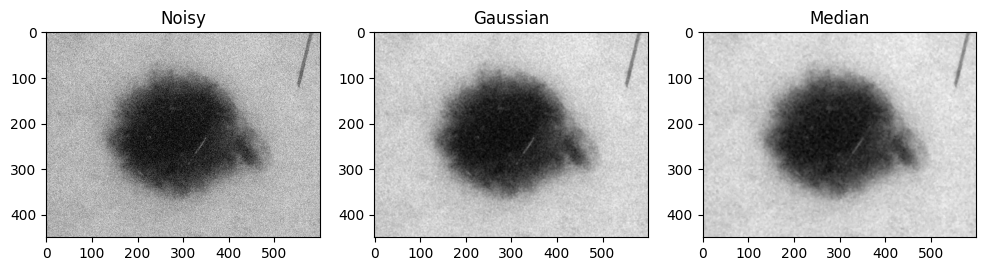

In [ ]:
def test_noise(path):
    import cv2
    import matplotlib.pyplot as plt

    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    noisy = add_noise(gray)
    gaussian = apply_gaussian(noisy)
    median = apply_median(noisy)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(noisy, cmap='gray')
    plt.title("Noisy")

    plt.subplot(1,3,2)
    plt.imshow(gaussian, cmap='gray')
    plt.title("Gaussian")

    plt.subplot(1,3,3)
    plt.imshow(median, cmap='gray')
    plt.title("Median")

    plt.show()

test_noise(sample_paths[0])

## Batch Processing

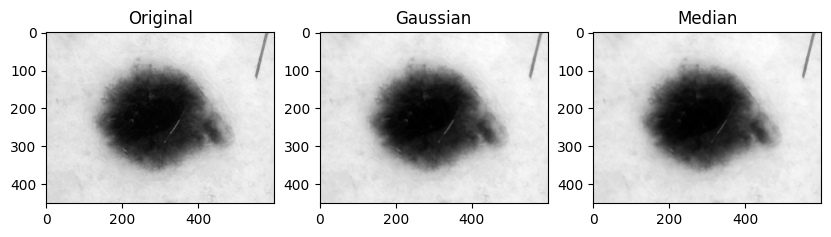

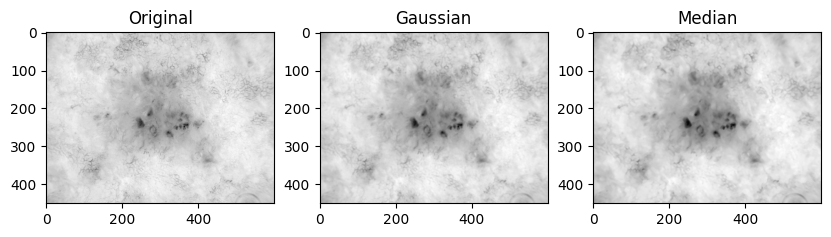

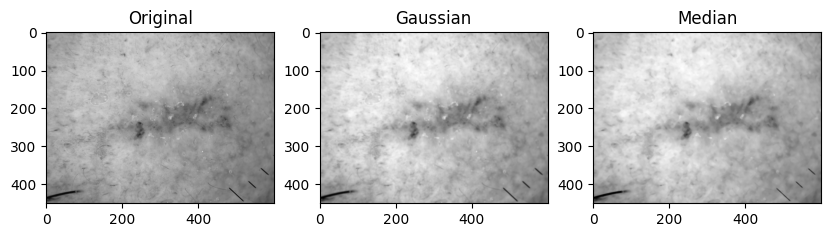

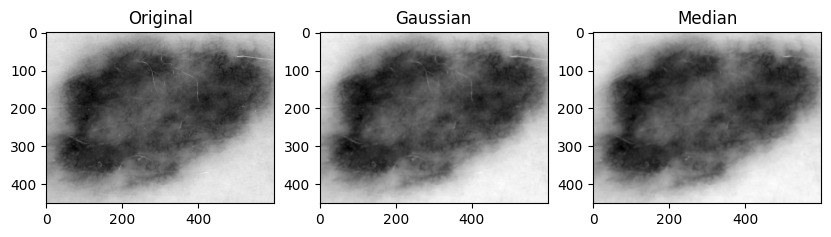

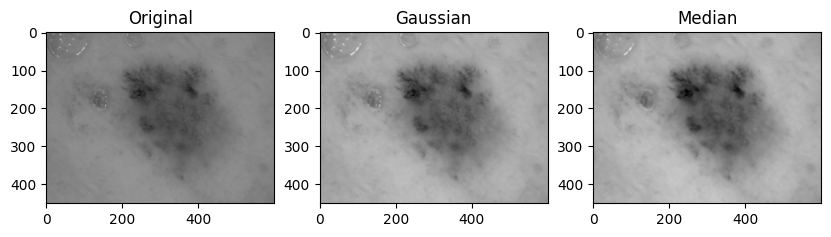

In [ ]:
def preprocess_multiple(sample_paths):
    import cv2
    import matplotlib.pyplot as plt

    for path in sample_paths[:5]:
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        gaussian = apply_gaussian(gray)
        median = apply_median(gray)

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.imshow(gray, cmap='gray')
        plt.title("Original")

        plt.subplot(1,3,2)
        plt.imshow(gaussian, cmap='gray')
        plt.title("Gaussian")

        plt.subplot(1,3,3)
        plt.imshow(median, cmap='gray')
        plt.title("Median")

        plt.show()

preprocess_multiple(sample_paths)

## Final Observations

- Gaussian filter is effective for smoothing images and reducing Gaussian noise  
- Median filter preserves edges better and is effective for salt-and-pepper noise  
- Choice of filter depends on noise type and application  

These preprocessing steps improve image quality before segmentation.